In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

fig_save_path = "/Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/AR_plots_new/"

In [2]:
cd ..

/Users/thomassainsbury/Documents/Mathis_lab/Mathis_lab_code/FreelyMovingVR4Mice/dj_pipeline


In [3]:
%run env_tom.py
%run run.py connect

2024-09-16 10:14:07,866::INFO::settings.py::Setting loglevel to INFO
2024-09-16 10:14:07,867::INFO::settings.py::Setting stores to {}
2024-09-16 10:14:07,867::INFO::settings.py::Setting database.misc.schema_prefix to 
2024-09-16 10:14:07,868::INFO::settings.py::Setting database.misc.create_tables to True
2024-09-16 10:14:07,868::INFO::settings.py::Setting enable_python_native_blobs to True
2024-09-16 10:14:07,868::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2024-09-16 10:14:07,869::INFO::settings.py::Setting database.user to thomas
2024-09-16 10:14:07,869::INFO::settings.py::Setting database.password to thomas


Connecting thomas@128.178.51.167:3309


2024-09-16 10:14:08,135::INFO::connection.py::Connected thomas@128.178.51.167:3309
2024-09-16 10:14:08,197::INFO::table.py::could not log event in table ~log
2024-09-16 10:14:08,643::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema import vr4mice, dlc, base_analysis
import vr4mice.analysis.plotting as plotting
import vr4mice.analysis.utils as utils
import vr4mice.analysis.visual_discrim_functions as vdf
from vr4mice.analysis import regression
vdf.get_rc_params()

In [5]:
pd.DataFrame((vr4mice.Box() & {"dataset": "Jacana_2024-07-26_1"}).fetch(as_dict=True)[0], index=[0])

,dataset,l_box_x_min,l_box_x_max,l_box_z_min,l_box_z_max,r_box_x_min,r_box_x_max,r_box_z_min,r_box_z_max,tt_box_x_min,tt_box_x_max,tt_box_z_min,tt_box_z_max,tt_box_angle
0,Jacana_2024-07-26_1,-10,-5,-4,-2,5,10,-4,-2,-4,4,-9,-5,90


In [6]:
dual_occuder = [{"dataset": "Nightingale_2024-08-14_1"},
                {"dataset": "Nightingale_2024-08-13_1"},
                {"dataset": "Nightingale_2024-08-12_1"},
                {"dataset": "Nightingale_2024-08-11_1"},
                {"dataset": "Nightingale_2024-08-10_1"},
                {"dataset": "Lemming_2024-08-13_1"},
                {"dataset": "Lemming_2024-08-12_1"},
                {"dataset": "Lemming_2024-08-11_1"},
                {"dataset": "Lemming_2024-08-10_1"},
                {"dataset": "Jacana_2024-08-13_1"},
                {"dataset": "Jacana_2024-08-14_1"},
                {"dataset": "Jacana_2024-08-15_1"},
                {"dataset": "Jacana_2024-08-16_1"},
                {"dataset": "Jacana_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-10_2"},
                {"dataset": "Kiwi_2024-08-11_4"},
                {"dataset": "Kiwi_2024-08-12_2"},
                {"dataset": "Kiwi_2024-08-13_1"},
                {"dataset": "Kiwi_2024-08-14_1"},
                {"dataset": "Oribi_2024-08-16_1"},
                {"dataset": "Oribi_2024-08-19_1"},
                {"dataset": "Oribi_2024-08-20_1"},
                {"dataset": "Oribi_2024-08-21_1"},
                {"dataset": "Oribi_2024-08-22_1"},
                {"dataset": "Pheasant_2024-08-15_2"},
                {"dataset": "Pheasant_2024-08-16_1"},
                {"dataset": "Pheasant_2024-08-20_1"},
                {"dataset": "Pheasant_2024-08-21_1"},
               ]


   



In [90]:
def get_all_in_list(data_set_list, training_stage="dual_occluder"):
    print(training_stage)
    big_df = []
    day = 0
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        df = dlc.SyncDLCWGame().get_data(key =  d)
        df ["mouse_name"] = split_d [0]
        df ["session"] = df ["dataset"]
        df ["date"] = split_d [1]
        df ["training_stage"] = training_stage
        big_df.append(df)
    big_df =  pd.concat(big_df).reset_index()
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max())
    first_n_samples =5
    big_df["norm_x"] = big_df.groupby("trial", as_index=False)["x"].transform(
        lambda x: x - np.mean(x.iloc[:first_n_samples]))
    big_df["norm_y"] = big_df.groupby("trial", as_index=False)["y"].transform(
        lambda x: x - np.mean(x.iloc[:first_n_samples]))
        
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max()
    )
    
    right_reward_x = big_df[(big_df.reward > 0.5) & (big_df.trial_right_choice > 0.5)]["x"].mean()
    right_reward_z = big_df[(big_df.reward > 0.5) & (big_df.trial_right_choice > 0.5)]["y"].mean()
    
    big_df["distance_to_reward"] = (np.array(((right_reward_x - big_df["x"] * big_df["flip_one_side"]) ** 2),dtype=np.float64) + 
                                    np.array(((right_reward_z - big_df["y"]) ** 2), dtype=np.float64))

    #big_df["velocity"][big_df ["velocity"] > 300] = np.nan
    #big_df["veloctiy"] =big_df["velocity"].interpolate().copy()
    return(big_df.reset_index(drop=True))



In [8]:
def get_j_shaped(big_df):
        # J-shaped trials
    j_shaped = big_df[
        (big_df.trial_duration <= 5) & (big_df.trial_rewarded > 0.5) & (big_df["trial_tortuosity"] <= 5)
    ]

    # stats: percentage of j shaped trials per session
    j_shaped_percentage = (
        j_shaped.groupby(["session"]).trial.nunique().values
        / big_df.groupby(["session"]).trial.nunique().values
    )
    print(j_shaped_percentage.mean(), stats.sem(j_shaped_percentage))
    return(j_shaped)

In [96]:
big_df = get_all_in_list(data_set_list = dual_occuder)


dual_occluder
['Nightingale', '2024-08-14', '1']
['Nightingale', '2024-08-13', '1']
['Nightingale', '2024-08-12', '1']
['Nightingale', '2024-08-11', '1']
['Nightingale', '2024-08-10', '1']
['Lemming', '2024-08-13', '1']
['Lemming', '2024-08-12', '1']
['Lemming', '2024-08-11', '1']
['Lemming', '2024-08-10', '1']
['Jacana', '2024-08-13', '1']
['Jacana', '2024-08-14', '1']
['Jacana', '2024-08-15', '1']
['Jacana', '2024-08-16', '1']
['Jacana', '2024-08-19', '1']
['Kiwi', '2024-08-10', '2']
['Kiwi', '2024-08-11', '4']
['Kiwi', '2024-08-12', '2']
['Kiwi', '2024-08-13', '1']
['Kiwi', '2024-08-14', '1']
['Oribi', '2024-08-16', '1']
['Oribi', '2024-08-19', '1']
['Oribi', '2024-08-20', '1']
['Oribi', '2024-08-21', '1']
['Oribi', '2024-08-22', '1']
['Pheasant', '2024-08-15', '2']
['Pheasant', '2024-08-16', '1']
['Pheasant', '2024-08-20', '1']
['Pheasant', '2024-08-21', '1']


In [102]:
df_types = pd.DataFrame(big_df.apply(pd.api.types.infer_dtype, axis=0)).reset_index().rename(columns={'index': 'column', 0: 'type'})

loop_types = df_types.values.tolist()

for col in loop_types:
    if col[1] == 'mixed':
        pass
    else:
        if col[1] == 'decimal':
            data_type = 'float64'
        elif col[1] == 'string':
            data_type = 'str'
        elif col[1] == 'integer':
            data_type = 'int'
        elif col [1] == "empty":
            data_type = "int"
        elif col[1] == 'floating':
            data_type = 'float64'
        elif col[1] == 'date':
            data_type = 'datetime64'
        else:
            data_type = col[1]
        big_df[col[0]] = big_df[col[0]].astype(data_type)

IndentationError: expected an indented block (3279794664.py, line 16)

In [101]:
df_types

,column,type
0,index,integer
1,dataset,string
2,step,floating
3,step_time,floating
4,trial,integer
5,reward,floating
6,x,floating
7,y,floating
8,bins_y,empty
9,norm_y,floating


In [23]:
def tranform_dlc_centers_to_rig_coords(head_center_x, head_center_y):
    cropped_image=[0, 530, 0, 510]
    unity_arena_size=[-9, 9, -10, -2]
    x = np.interp(np.array(head_center_x, np.float16),
                [cropped_image[0], cropped_image[1]],
                [unity_arena_size[0], unity_arena_size[1]],
            )
    y = np.interp(np.array(head_center_y, np.float16),
                [cropped_image[2], cropped_image[3]],
                [unity_arena_size[2], unity_arena_size[3]],
            )
    x = np.interp(x, [-9, 9], [-27, 27])
    y = np.interp(y, [-10, -2], [-27, 27])
    return(x, y)
    
 

2024-09-09 13:16:07,641::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-09 13:16:07,652::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-09 13:16:07,701::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-09 13:16:07,705::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-09 13:16:07,803::INFO::category.py::Using categorical un

                mean       sem
aperture                      
4.3       121.821429  1.891259
12.0      123.821429  2.058055


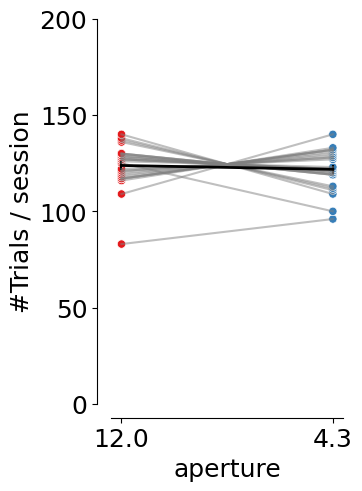

In [10]:
fig,ax = plt.subplots(1,1, figsize = (3,5))
plotting.plot_trial_count(df=big_df, ax=ax, alpha=0.5, per_aperture=True)
plt.ylim(0,200)
sns.despine(offset=10)
plt.savefig(fig_save_path + "dual_occluder_trial_number.svg", transparent=True)

2024-09-16 10:42:04,060::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-16 10:42:04,218::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-16 10:42:04,610::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-16 10:42:04,613::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-16 10:42:04,765::INFO::category.py::Using categorical un

              mean       sem
aperture                    
12.0      0.860919  0.014092
4.3       0.796493  0.015558


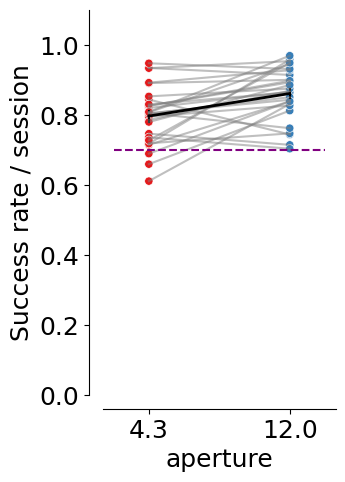

In [62]:
fig,ax = plt.subplots(1,1, figsize = (3,5))
plotting.plot_rewards(df=big_df, ax=ax, alpha=0.5, per_aperture=True)
plt.ylim(0,1.1)
sns.despine(offset=10)
plt.savefig(fig_save_path + "dual_occluder_rewards.svg", transparent=True)

In [95]:
big_df = convert_column_type(big_df)
j_shaped = get_j_shaped(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")

AttributeError: 'Series' object has no attribute 'columns'

In [88]:
j_shaped

,index,dataset,step,step_time,trial,reward,x,y,bins_y,norm_y,...,date,training_stage,session_increment,norm_x,distance_to_reward,head_center_x_trans,head_ceter_y_trans,head_center_y_trans,bins,bin_centers
47,51,nan,1294.5,17.771338,3,0.0,7.457585,7.925065,nan,-0.961857,...,nan,nan,1,0.660820,267.031616,6.316981,9.476471,9.476471,"(7.664, 8.121]",7.8925
48,52,nan,1296.0,17.790837,3,0.0,7.042265,8.617934,nan,-0.268988,...,nan,nan,1,0.245500,258.650198,5.782075,10.402941,10.402941,"(8.578, 9.034]",8.8060
49,53,nan,1297.5,17.811339,3,0.0,6.102727,9.982681,nan,1.095759,...,nan,nan,1,-0.694038,248.774137,4.737736,11.938235,11.938235,"(9.948, 10.405]",10.1765
50,54,nan,1299.0,17.830837,3,0.0,5.412459,11.167965,nan,2.281043,...,nan,nan,1,-1.384306,241.533099,4.228302,12.705882,12.705882,"(10.862, 11.319]",11.0905
51,55,nan,1300.5,17.851340,3,0.0,5.138060,11.600396,nan,2.713474,...,nan,nan,1,-1.658705,240.396951,3.718868,13.341176,13.341176,"(11.319, 11.776]",11.5475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430057,11444,nan,176615.0,2382.030534,250,0.0,15.272628,20.880139,nan,26.617267,...,nan,nan,28,19.045935,6.220484,16.683962,21.202941,21.202941,NaN,NaN
430058,11445,nan,176616.5,2382.050037,250,0.0,16.342392,20.963053,nan,26.700181,...,nan,nan,28,20.115699,2.109640,17.397170,21.229412,21.229412,NaN,NaN
430059,11446,nan,176618.0,2382.070535,250,0.0,16.574588,20.979596,nan,26.716724,...,nan,nan,28,20.347895,1.520431,18.416038,21.176471,21.176471,NaN,NaN
430060,11447,nan,176619.5,2382.090534,250,0.0,17.545746,21.036036,nan,26.773164,...,nan,nan,28,21.319053,0.219761,18.823585,21.176471,21.176471,NaN,NaN


In [87]:
mean_mouse = j_shaped.groupby(
    ["session","mouse_name", "training_stage", "date","dataset", "choice", "aperture", "bin_centers"], as_index=False
).mean().copy()

TypeError: Could not convert nannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannannanna

In [84]:
# Example usage
# Assuming df is your dataframe




index                    int64
dataset                 object
step                   float64
step_time              float64
trial                    int64
                        ...   
norm_x                 float64
distance_to_reward     float64
head_center_x_trans    float64
head_ceter_y_trans     float64
head_center_y_trans    float64
Length: 61, dtype: object

ValueError: Could not interpret value `x` for `y`. An entry with this name does not appear in `data`.

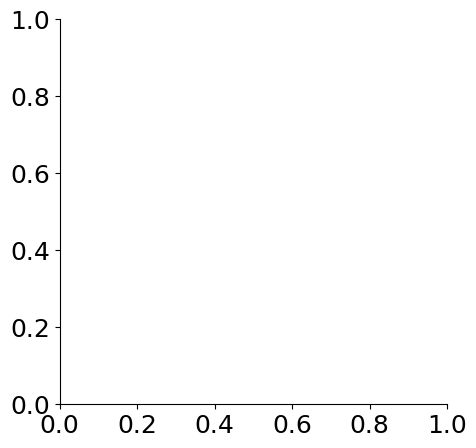

In [76]:
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")


fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x="bin_centers",
    y="x",
    hue="choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-15,15)
plt.savefig(fig_save_path + "dual_occluder_aperture_mean_traj.svg", transparent=True)

In [ ]:
big_df.keys()

In [ ]:
big_df.head()

In [ ]:
mean_mouse = interpolated_j_shaped.groupby(
    ["session", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()

for i, label in enumerate(
    ["velocity_x_fliped", "velocity_y", "velocity", "distance_to_reward"]
):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else colors_aperture
        ),
        hue="aperture",
        # style="trial_L_choice",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_title(f"{label}")
plt.tight_layout(pad=2)

In [ ]:
plt.plot(big_df ["norm_y"])
plt.plot((big_df ["norm_x"]*0.5)-30)
plt.plot(big_df ["head_angle"]*0.1-60)
plt.plot(big_df ["iti"]*100)
plt.xlim(0,1000)
plt.ylim(-80,40)

In [ ]:
j_shaped = get_j_shaped(big_df)

In [ ]:
j_shaped = utils.create_bins(data=j_shaped, spatial_ybins=[6.75, 20, 30], label="y")
mean_mouse = j_shaped.groupby(
    ["session", "choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only=True)

In [ ]:
columns = [
    "y",
    "heading_dir",
    "head_angle",
    "trial_tortuosity",
    "trial_init_x",
    "trial_duration",
    "x",
    "norm_x",
    "trial_init_y",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "acceleration_x",
    "heading_dir_velocity",
    "trial_traj_path_length",
    "trial_rewarded",
    "heading_dir_acceleration",
    "norm_y",
    "flip_one_side",
    "distance_to_reward",
]

interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=200, value_columns=["trial_left_choice"] + columns
)
interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["session", "trial"]
).trial.cumcount()
interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / 200

interpolated_j_shaped["velocity_x_fliped"] = (
    interpolated_j_shaped["velocity_x"] * interpolated_j_shaped["flip_one_side"]
)
interpolated_j_shaped["head_dir_re"] = interpolated_j_shaped["heading_dir"] - 90

In [ ]:
model_labels = [
    "norm_x",
    "norm_y",
    "heading_dir",
    "head_angle",
    "trial_tortuosity",
    "trial_duration",
    "trial_init_x",
    "trial_init_y",
    "trial_traj_path_length",
    "aperture",
    "trial_rewarded",
    "distance_to_reward",
]

In [ ]:
df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=model_labels, n_splits=10, per_mouse=True
)

In [ ]:
fig, ax = plt.subplots(1, 1)
trials = range(10, 50)
group = df_model[(df_model.trial.isin(trials)) & (df_model.session == dual_occuder[2]["dataset"])]

sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=[plotting.colors_choice[1], plotting.colors_choice[0]],
    ax=ax,
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")

In [ ]:
trials = range(45, 50)
group = df_model[(df_model.trial.isin(trials)) & (df_model.session == dual_occuder[2]["dataset"])]

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 4))

mean_mouse = df_model.groupby(["session", "aperture", "trial_length"]).mean(
    numeric_only=True
)

mean_mouse_per_choice = df_model.groupby(
    ["session", "trial_left_choice", "aperture", "trial_length"]
).mean(numeric_only=True)

# Accuracy
sns.lineplot(
    ax=ax[0],
    data=mean_mouse,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=(
        plotting.colors_aperture[:2] if len(df_model.aperture.unique()) == 2 else colors_aperture
    ),
    errorbar="se",
)
ax[0].hlines(xmin=0, xmax=1, y=0.5, linestyles="dashed", color="k")
ax[0].set_ylim(0.4, 1)

# P(Left)
sns.lineplot(
    ax=ax[1],
    data=mean_mouse_per_choice,
    y="proba_left",
    x="trial_length",
    hue="trial_left_choice" if len(df_model.aperture.unique()) == 2 else "aperture",
    style="aperture" if len(df_model.aperture.unique()) == 2 else "trial_left_choice",
    palette=(
        [plotting.colors_choice[1], plotting.colors_choice[0]]
        if len(df_model.aperture.unique()) == 2
        else "viridis"
    ),
)
ax[1].hlines(xmin=0, xmax=1, y=0.5, linestyles="dashed", color="k")
ax[1].hlines(xmin=0, xmax=1, y=0.8, linestyles="dotted", color="grey")
ax[1].hlines(xmin=0, xmax=1, y=0.2, linestyles="dotted", color="grey")

# Logits of the regression
ax[2].bar(
    np.arange(coef[:, 1:].shape[1]),
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
)

plt.tight_layout(pad=1.0)
plt.show()

In [ ]:
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plotting.plot_decision_point(decision_points, label_parameter="y", ax=ax)

In [ ]:
trial = 5
plt.scatter(df.)